In [1]:
import matplotlib
import matplotlib.lines as lines
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(os.path.join("/data/swein/Documents")))

In [2]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

matplotlib.rc("font", size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc("axes", titlesize=MEDIUM_SIZE)     # fontsize of the axes title
matplotlib.rc("axes", labelsize=SMALL_SIZE)    # fontsize of the x and y labels
matplotlib.rc("xtick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("ytick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("legend", fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc("figure", titlesize=MEDIUM_SIZE)  # fontsize of the figure title

In [3]:
from ggwd.utils.configreader import ConfigReader
from ggwd.utils.samplegenerator import SampleGenerator

/usr/lib/python3.12/importlib/__init__.py:90: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


/data/swein/venvs/ggwd_env/lib/python3.12/site-packages/pycbc/types/array.py:393: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)
/data/swein/venvs/ggwd_env/lib/python3.12/site-packages/pycbc/types/array.py:438: RuntimeWarning: invalid value encountered in power
  return self._data ** other
/data/swein/venvs/ggwd_env/lib/python3.12/site-packages/pycbc/types/array.py:386: RuntimeWarning: invalid value encountered in divide
  return self._data / other
/tmp/ipykernel_2300327/1829707683.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(frameon=False, loc=1)


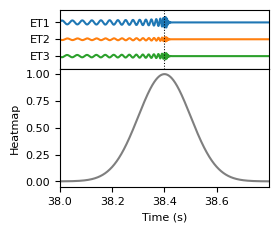

In [4]:
config_reader = ConfigReader("one_signal.ini")   
sample_parameters = config_reader.sample_parameters
td_length  = config_reader.sample_parameters["td_length"]
delta_t = config_reader.sample_parameters["delta_t"]
time = np.arange(int(td_length))*delta_t
sample_length = int(td_length)*delta_t

sample_generator = SampleGenerator("one_signal.ini")   
rng = np.random.default_rng()
np.random.seed(42)
out = sample_generator._generate_sample(rng)

waveform = np.array([out["waveform"]["e1"], out["waveform"]["e2"], out["waveform"]["e3"]])
merger_time = out["parameters"]["waveform_parameters"]["merger_time"]
heatmap = np.zeros(td_length)
for t in merger_time:
    if np.isnan(t): continue
    t *= td_length * delta_t
    sigma_in_seconds = 0.1
    gaussian = np.exp(-np.power((time-t)/sigma_in_seconds, 2) / 2)
    i0 = min(0, int((sigma_in_seconds)/delta_t))
    i1 = max(td_length-1, int((t+3*sigma_in_seconds)/delta_t))
    gaussian[:i0] = 0
    gaussian[i1:] = 0
    heatmap = np.maximum.reduce((heatmap, gaussian))

fig, axs = plt.subplots(nrows=2, sharex=True, figsize=(7/2.54, 6/2.54), 
                        height_ratios=(1, 2))

sample_length = time[-1]
x0, x1 = np.min(merger_time)*sample_length, np.max(merger_time)*sample_length
delta = 0.4
mask = np.logical_and(x0-delta<time, time<=x1+delta)
x = time[mask]
y = waveform[:,mask]

max_strain = 1.5E-23
ticks = list()
for i, strain in enumerate(waveform):
    axs[0].plot(time, 3/2*(1-i)*max_strain+strain)
    ticks.append(3/2*(1-i)*max_strain)
for t in merger_time:
    axs[0].axvline(t*sample_length, ls="dotted", lw=0.75, c="k")
axs[0].set_yticks(ticks, ["ET1", "ET2", "ET3"])
axs[0].set_ylim(-1.05*5/2*max_strain, 1.05*5/2*max_strain)

axs[1].plot(x, heatmap[mask], c="tab:gray")

axs[0].set_xlim(x[0], x[-1])    
axs[1].set_ylim(-0.05, 1.05)    
axs[1].legend(frameon=False, loc=1)

axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Heatmap")

axs[0].tick_params(axis="x", which="both", bottom=False, 
                    labelbottom=False)
fig.tight_layout()
fig.subplots_adjust(hspace=0)
fig.savefig("heatmap_one_signal.png", dpi=300)

/data/swein/venvs/ggwd_env/lib/python3.12/site-packages/pycbc/types/array.py:393: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)
/data/swein/venvs/ggwd_env/lib/python3.12/site-packages/pycbc/types/array.py:438: RuntimeWarning: invalid value encountered in power
  return self._data ** other
/data/swein/venvs/ggwd_env/lib/python3.12/site-packages/pycbc/types/array.py:386: RuntimeWarning: invalid value encountered in divide
  return self._data / other
/tmp/ipykernel_2300327/2031298141.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(frameon=False, loc=1)


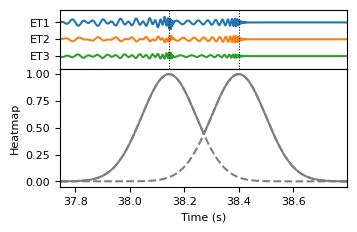

In [5]:
config_reader = ConfigReader("two_signals.ini")   
sample_parameters = config_reader.sample_parameters
td_length  = config_reader.sample_parameters["td_length"]
delta_t = config_reader.sample_parameters["delta_t"]
time = np.arange(int(td_length))*delta_t
sample_length = int(td_length)*delta_t

sample_generator = SampleGenerator("two_signals.ini")   
rng = np.random.default_rng()
np.random.seed(42)
out = sample_generator._generate_sample(rng)

waveform = np.array([out["waveform"]["e1"], out["waveform"]["e2"], out["waveform"]["e3"]])
merger_time = out["parameters"]["waveform_parameters"]["merger_time"]
gaussians = np.zeros((np.isfinite(merger_time).sum(),td_length))
heatmap = np.zeros(td_length)
for i, t in enumerate(merger_time):
    if np.isnan(t): continue
    t *= td_length * delta_t
    sigma_in_seconds = 0.1
    gaussian = np.exp(-np.power((time-t)/sigma_in_seconds, 2) / 2)
    i0 = min(0, int((sigma_in_seconds)/delta_t))
    i1 = max(td_length-1, int((t+3*sigma_in_seconds)/delta_t))
    gaussian[:i0] = 0
    gaussian[i1:] = 0
    gaussians[i] = gaussian
    heatmap = np.maximum.reduce((heatmap, gaussian))

fig, axs = plt.subplots(nrows=2, sharex=True, figsize=(9/2.54, 6/2.54), 
                        height_ratios=(1, 2))

sample_length = time[-1]
x0, x1 = np.min(merger_time)*sample_length, np.max(merger_time)*sample_length
delta = 0.4
mask = np.logical_and(x0-delta<time, time<=x1+delta)
x = time[mask]
y = waveform[:,mask]

max_strain = 1.5E-23
ticks = list()
for i, strain in enumerate(waveform):
    axs[0].plot(time, 3/2*(1-i)*max_strain+strain)
    ticks.append(3/2*(1-i)*max_strain)
for t in merger_time:
    axs[0].axvline(t*sample_length, ls="dotted", lw=0.75, c="k")
axs[0].set_yticks(ticks, ["ET1", "ET2", "ET3"])
axs[0].set_ylim(-1.05*5/2*max_strain, 1.05*5/2*max_strain)

for g in gaussians: axs[1].plot(x, g[mask], c="tab:gray", ls="--")
axs[1].plot(x, heatmap[mask], c="tab:gray")


axs[0].set_xlim(x[0], x[-1])    
axs[1].set_ylim(-0.05, 1.05)    
axs[1].legend(frameon=False, loc=1)

axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Heatmap")

axs[0].tick_params(axis="x", which="both", bottom=False, 
                    labelbottom=False)
fig.tight_layout()
fig.subplots_adjust(hspace=0)
fig.savefig("heatmap_two_signals.png", dpi=300)

In [6]:
config_reader = ConfigReader("three_signals.ini")   
sample_parameters = config_reader.sample_parameters
td_length  = config_reader.sample_parameters["td_length"]
delta_t = config_reader.sample_parameters["delta_t"]
time = np.arange(int(td_length))*delta_t
sample_length = int(td_length)*delta_t

sample_generator = SampleGenerator("three_signals.ini")   
rng = np.random.default_rng()
np.random.seed(42)
out = sample_generator._generate_sample(rng)

waveform = np.array([out["waveform"]["e1"], out["waveform"]["e2"], out["waveform"]["e3"]])
merger_time = out["parameters"]["waveform_parameters"]["merger_time"]
gaussians = np.zeros((np.isfinite(merger_time).sum(),td_length))
heatmap = np.zeros(td_length)
for i, t in enumerate(merger_time):
    if np.isnan(t): continue
    t *= td_length * delta_t
    sigma_in_seconds = 0.1
    gaussian = np.exp(-np.power((time-t)/sigma_in_seconds, 2) / 2)
    i0 = min(0, int((sigma_in_seconds)/delta_t))
    i1 = max(td_length-1, int((t+3*sigma_in_seconds)/delta_t))
    gaussian[:i0] = 0
    gaussian[i1:] = 0
    gaussians[i] = gaussian
    heatmap = np.maximum.reduce((heatmap, gaussian))

/data/swein/venvs/ggwd_env/lib/python3.12/site-packages/pycbc/types/array.py:393: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)
/data/swein/venvs/ggwd_env/lib/python3.12/site-packages/pycbc/types/array.py:438: RuntimeWarning: invalid value encountered in power
  return self._data ** other
/data/swein/venvs/ggwd_env/lib/python3.12/site-packages/pycbc/types/array.py:386: RuntimeWarning: invalid value encountered in divide
  return self._data / other


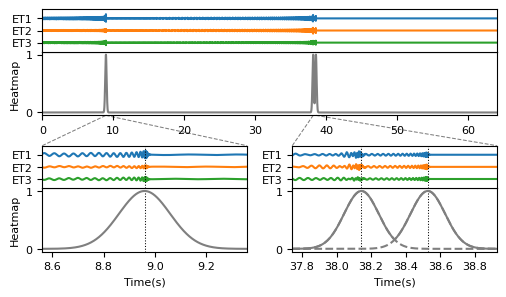

In [7]:
plot_height = 3.5
margin = 1
ratio = (1, 1.5)
ratio = (ratio[0]/(ratio[0]+ratio[1]), ratio[1]/(ratio[0]+ratio[1]))
fig_width, fig_height = 15, (margin+2*plot_height)
a = 3.3
fig = plt.figure(figsize=(fig_width/a,fig_height/a))
ax0_1 = fig.add_axes(rect=(0,(plot_height+margin)/fig_height,1,ratio[1]*plot_height/fig_height))
ax0_0 = fig.add_axes(rect=(0,((ratio[1]+1)*plot_height+margin)/fig_height,1,ratio[0]*plot_height/fig_height), sharex=ax0_1)
ax0_0.axes.get_xaxis().set_visible(False)
ax1_1 = fig.add_axes(rect=(0,0,0.45,ratio[1]*plot_height/fig_height))
ax1_0 = fig.add_axes(rect=(0,ratio[1]*plot_height/fig_height,0.45,ratio[0]*plot_height/fig_height), sharex=ax1_1)
ax1_0.axes.get_xaxis().set_visible(False)
ax2_1 = fig.add_axes(rect=(0.55,0,0.45,ratio[1]*plot_height/fig_height))
ax2_0 = fig.add_axes(rect=(0.55,ratio[1]*plot_height/fig_height,0.45,ratio[0]*plot_height/fig_height), sharex=ax2_1)
ax2_0.axes.get_xaxis().set_visible(False)


max_strain = 1.5E-23
ticks = list()
for i, strain in enumerate(waveform):
    ax0_0.plot(time, 3/2*(1-i)*max_strain+strain)
    ticks.append(3/2*(1-i)*max_strain)
ax0_0.set_yticks(ticks, ["ET1", "ET2", "ET3"])
ax0_0.set_ylim(-1.05*5/2*max_strain, 1.05*5/2*max_strain)

ax0_1.plot(time, heatmap, c="tab:gray")

ax0_1.set_xlim(time[0], time[-1])    
ax0_1.set_ylabel("Heatmap") 

sample_length = time[-1]
x0, x1 = np.min(merger_time[0])*sample_length, np.max(merger_time[0])*sample_length
delta = 0.4
mask = np.logical_and(x0-delta<time, time<=x1+delta)
x = time[mask]
y = waveform[:,mask]

max_strain = 1.5E-23
ticks = list()
for i, strain in enumerate(waveform):
    ax1_0.plot(time, 3/2*(1-i)*max_strain+strain)
    ticks.append(3/2*(1-i)*max_strain)
for t in merger_time:
    ax1_0.axvline(t*sample_length, ls="dotted", lw=0.75, c="k")
    ax1_1.axvline(t*sample_length, ls="dotted", lw=0.75, c="k")
ax1_0.set_yticks(ticks, ["ET1", "ET2", "ET3"])
ax1_0.set_ylim(-1.05*5/2*max_strain, 1.05*5/2*max_strain)

ax1_1.plot(x, heatmap[mask], c="tab:gray")

ax1_1.set_xlim(x[0], x[-1])    
ax1_1.set_xlabel("Time(s)")
ax1_1.set_ylabel("Heatmap")

fig.add_artist(lines.Line2D([0, x0/sample_length], 
                            [plot_height/fig_height, (plot_height+margin)/fig_height], 
                            c="k", lw=0.75, ls="--", alpha=0.5))
fig.add_artist(lines.Line2D([x1/sample_length, 0.45], 
                            [(plot_height+margin)/fig_height, plot_height/fig_height], 
                            c="k", lw=0.75, ls="--", alpha=0.5))
# fig.add_artist(lines.Line2D([x0/sample_length, x0/sample_length], 
#                             [(plot_height+margin)/fig_height, 1], 
#                             c="k", lw=0.75, alpha=0.5))
# fig.add_artist(lines.Line2D([x1/sample_length, x1/sample_length], 
#                             [(plot_height+margin)/fig_height, 1], 
#                             c="k", lw=0.75, alpha=0.5))

sample_length = time[-1]
x0, x1 = np.min(merger_time[1:])*sample_length, np.max(merger_time[1:])*sample_length
mask = np.logical_and(x0-delta<time, time<=x1+delta)
x = time[mask]
y = waveform[:,mask]

max_strain = 1.5E-23
ticks = list()
for i, strain in enumerate(waveform):
    ax2_0.plot(time, 3/2*(1-i)*max_strain+strain)
    ticks.append(3/2*(1-i)*max_strain)
for t in merger_time:
    ax2_0.axvline(t*sample_length, ls="dotted", lw=0.75, c="k")
    ax2_1.axvline(t*sample_length, ls="dotted", lw=0.75, c="k")
ax2_0.set_yticks(ticks, ["ET1", "ET2", "ET3"])
ax2_0.set_ylim(-1.05*5/2*max_strain, 1.05*5/2*max_strain)

for g in gaussians[1:]: ax2_1.plot(x, g[mask], c="tab:gray", ls="--")
ax2_1.plot(x, heatmap[mask], c="tab:gray")

ax2_1.set_xlim(x[0], x[-1])    
ax2_1.set_xlabel("Time(s)")

fig.add_artist(lines.Line2D([0.55, x0/sample_length], 
                            [plot_height/fig_height, (plot_height+margin)/fig_height], 
                            c="k", lw=0.75, ls="--", alpha=0.5))
fig.add_artist(lines.Line2D([x1/sample_length, 1], 
                            [(plot_height+margin)/fig_height, plot_height/fig_height], 
                            c="k", lw=0.75, ls="--", alpha=0.5))
# fig.add_artist(lines.Line2D([x0/sample_length, x0/sample_length], 
#                             [(plot_height+margin)/fig_height, 1], 
#                             c="k", lw=0.75, alpha=0.5))
# fig.add_artist(lines.Line2D([x1/sample_length, x1/sample_length], 
#                             [(plot_height+margin)/fig_height, 1], 
#                             c="k", lw=0.75, alpha=0.5))

fig.savefig("sample.png", dpi=300, bbox_inches="tight")